In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from utils import load_data

X_train, X_test, y_train, y_test = load_data()


In [ ]:
# 1. Label Encoding 
# Same as Decision Tree — no one-hot needed, no scaling needed.
# The simplicity of preprocessing for tree-based models becomes
# very apparent by now compared to Logistic Regression and SVM.
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in categorical_cols:
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col]  = le.transform(X_test[col])

print("Preprocessing: Label encoded only, no scaling")
print("Feature shape:", X_train_enc.shape)

Preprocessing: Label encoded only, no scaling
Feature shape: (1176, 30)


C:\Users\shrad\AppData\Local\Temp\ipykernel_31200\3547967675.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
# 2. Single tree vs Random Forest — the core comparison 
# Let's directly compare a single decision tree against a forest
# using the same depth settings to isolate the ensemble effect.
from sklearn.tree import DecisionTreeClassifier

single_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42)
single_tree.fit(X_train_enc, y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,           # prevents trees from going too deep
    min_samples_split=10,   # node must have 10+ samples to split
    min_samples_leaf=4,     # each leaf must have 4+ samples
    class_weight="balanced",
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_enc, y_train)

tree_train_auc = roc_auc_score(y_train, single_tree.predict_proba(X_train_enc)[:, 1])
tree_test_auc  = roc_auc_score(y_test,  single_tree.predict_proba(X_test_enc)[:, 1])
rf_train_auc   = roc_auc_score(y_train, rf.predict_proba(X_train_enc)[:, 1])
rf_test_auc    = roc_auc_score(y_test,  rf.predict_proba(X_test_enc)[:, 1])

print(f"\n── Single Tree vs Random Forest ──")
print(f"{'':20} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print(f"{'Single Decision Tree':20} {tree_train_auc:>10.4f} {tree_test_auc:>10.4f} {tree_train_auc - tree_test_auc:>8.4f}")
print(f"{'Random Forest (200)':20} {rf_train_auc:>10.4f} {rf_test_auc:>10.4f} {rf_train_auc - rf_test_auc:>8.4f}")
# The gap (Train AUC - Test AUC) directly measures overfitting.
# Random Forest's gap will be smaller.

print(f"\nOOB Score: {rf.oob_score_:.4f}")
# OOB score is a free estimate of test performance. 


── Single Tree vs Random Forest ──
                      Train AUC   Test AUC      Gap
Single Decision Tree     1.0000     0.5720   0.4280
Random Forest (200)      0.9950     0.7821   0.2129

OOB Score: 0.8571


In [ ]:
# 3. n_estimators experiment 
# How many trees are actually needed? More trees = more stable,
# but there are diminishing returns 
print("\n── Effect of n_estimators ──")
n_estimator_range = [10, 25, 50, 100, 200, 300, 500]
ne_train_aucs = []
ne_test_aucs  = []

for n in n_estimator_range:
    rf_n = RandomForestClassifier(n_estimators=n, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
    rf_n.fit(X_train_enc, y_train)
    ne_train_aucs.append(roc_auc_score(y_train, rf_n.predict_proba(X_train_enc)[:, 1]))
    ne_test_aucs.append(roc_auc_score(y_test,   rf_n.predict_proba(X_test_enc)[:, 1]))
    print(f"n_estimators={n:<5} | Train AUC: {ne_train_aucs[-1]:.4f} | Test AUC: {ne_test_aucs[-1]:.4f}")


── Effect of n_estimators ──
n_estimators=10    | Train AUC: 0.9997 | Test AUC: 0.6992
n_estimators=25    | Train AUC: 1.0000 | Test AUC: 0.7392
n_estimators=50    | Train AUC: 1.0000 | Test AUC: 0.7533
n_estimators=100   | Train AUC: 1.0000 | Test AUC: 0.7574
n_estimators=200   | Train AUC: 1.0000 | Test AUC: 0.7862
n_estimators=300   | Train AUC: 1.0000 | Test AUC: 0.7873
n_estimators=500   | Train AUC: 1.0000 | Test AUC: 0.7881


In [ ]:
# 4. Feature importances 
# Random Forest averages feature importances across ALL trees.
# This is more stable and reliable than a single tree's importances
# because no single tree's quirks dominate the result.
importances = pd.Series(rf.feature_importances_, index=X_train_enc.columns)
importances_sorted = importances.sort_values(ascending=False)

print(f"\nTop 10 features (averaged across {rf.n_estimators} trees):")
print(importances_sorted.head(10))


Top 10 features (averaged across 200 trees):
MonthlyIncome           0.086586
Age                     0.071000
TotalWorkingYears       0.062299
OverTime                0.061773
YearsAtCompany          0.053582
DailyRate               0.048844
YearsWithCurrManager    0.044825
DistanceFromHome        0.044320
MonthlyRate             0.042828
StockOptionLevel        0.041510
dtype: float64


In [ ]:


# 5. Individual tree disagreement 
# Let's peek at how much individual trees disagree with each other.
# This disagreement (variance) is what bagging reduces.
sample_idx = 0
first_sample = X_test_enc.iloc[[sample_idx]]
individual_preds = [tree.predict_proba(first_sample)[0][1]
                    for tree in rf.estimators_[:50]]

print(f"\nFirst 50 trees' probability for test sample 0:")
print([round(p, 3) for p in individual_preds])
print(f"Mean: {np.mean(individual_preds):.3f} | Std: {np.std(individual_preds):.3f}")
print(f"Final RF prediction: {rf.predict_proba(first_sample)[0][1]:.3f}")
# The individual predictions will vary widely. the average is what matters



First 50 trees' probability for test sample 0:
[np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean: 0.480 | Std: 0.500
Final RF prediction: 0.480


c:\Users\shrad\OneDrive\Documents\ml practice\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\shrad\OneDrive\Documents\ml practice\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\shrad\OneDrive\Documents\ml practice\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\shrad\OneDrive\Documents\ml practice\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\shrad\OneDrive\Documents\ml practice\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Dec

In [ ]:
# 6. Final evaluation 
y_pred       = rf.predict(X_test_enc)
y_pred_proba = rf.predict_proba(X_test_enc)[:, 1]

print(f"\n── Random Forest Final Results ──")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")



── Random Forest Final Results ──
              precision    recall  f1-score   support

          No       0.85      0.98      0.91       247
         Yes       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294

AUC: 0.7862


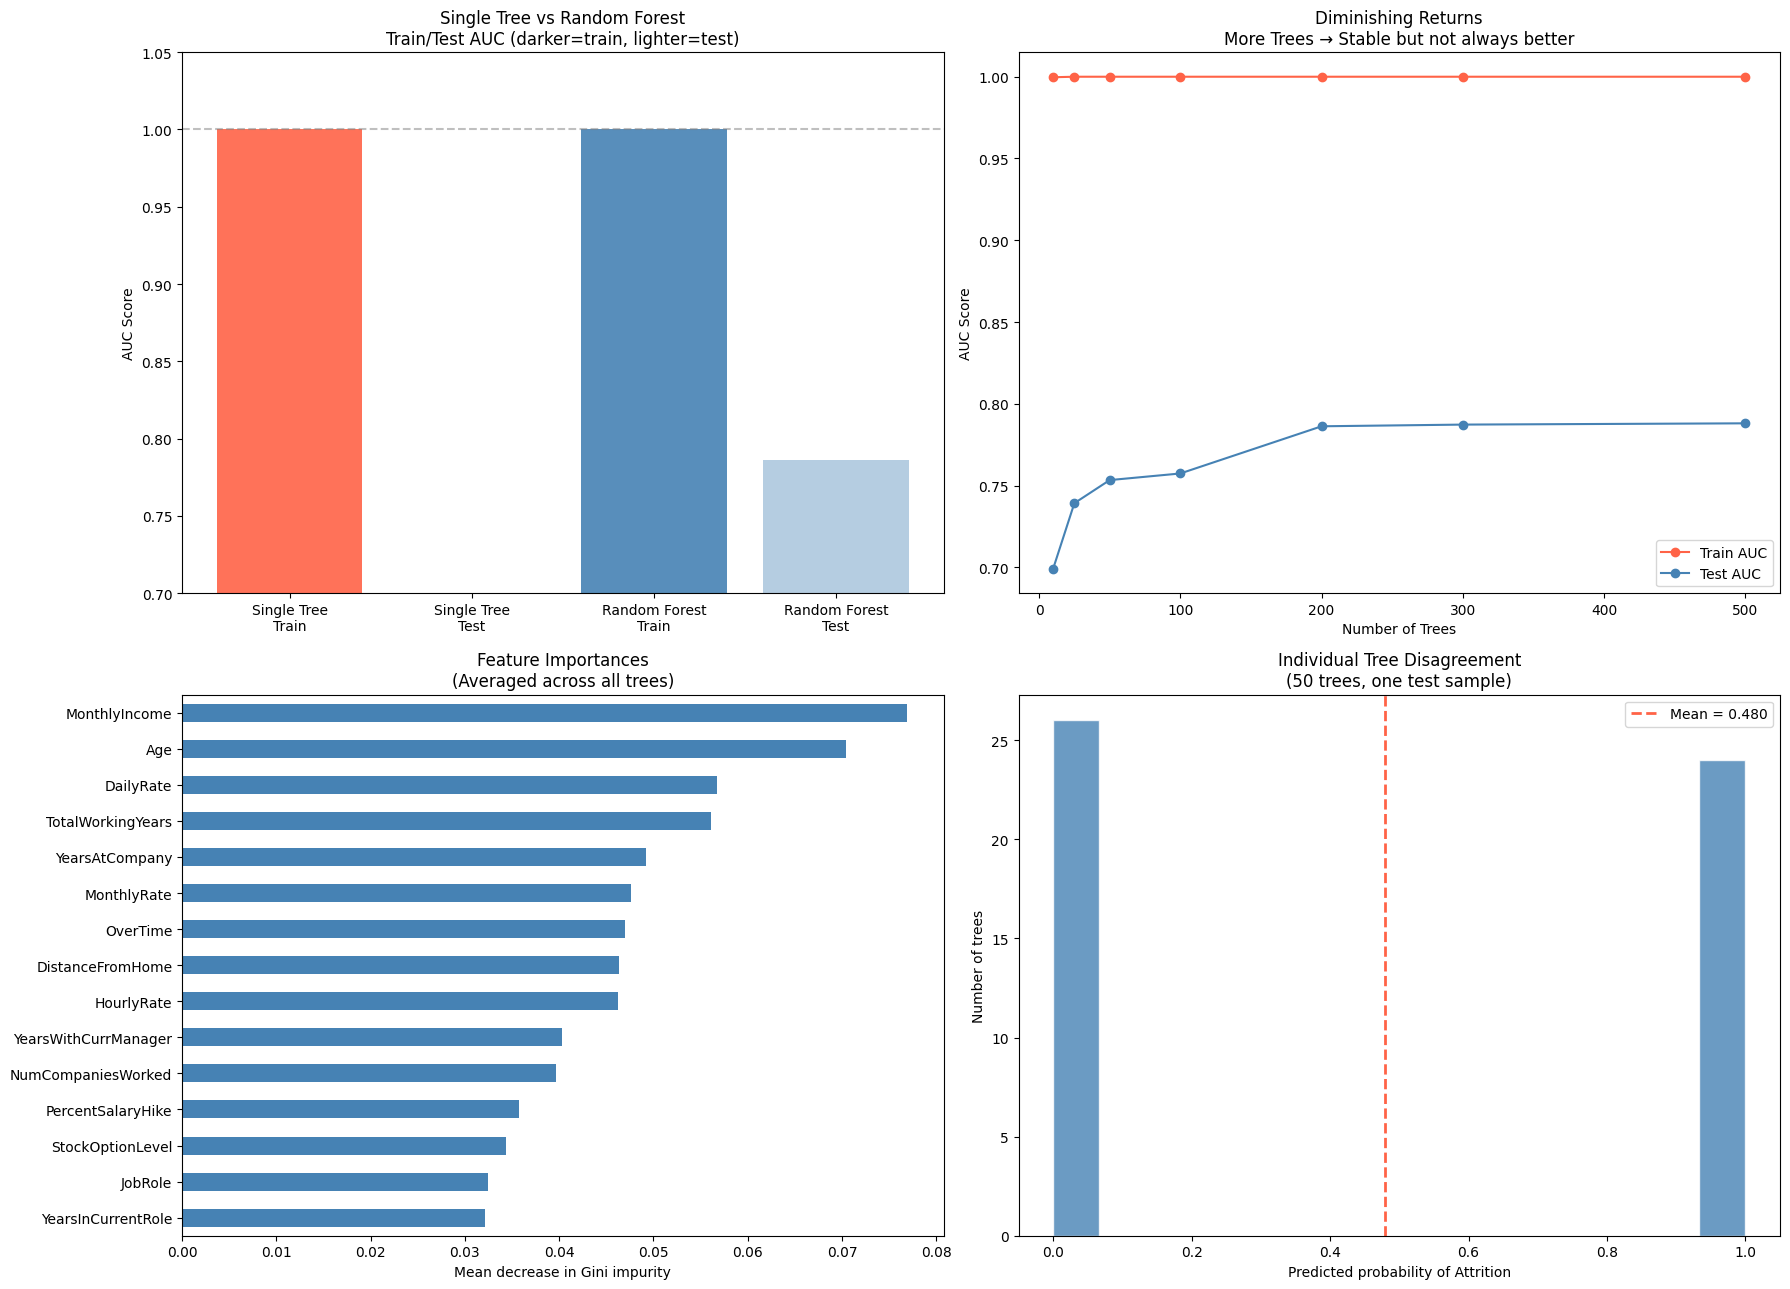

In [ ]:
# 7. Plots 
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Plot 1: Single tree vs RF — train/test AUC gap
labels   = ["Single Tree\nTrain", "Single Tree\nTest",
            "Random Forest\nTrain", "Random Forest\nTest"]
values   = [tree_train_auc, tree_test_auc, rf_train_auc, rf_test_auc]
colors   = ["tomato", "tomato", "steelblue", "steelblue"]
alphas   = [0.9, 0.4, 0.9, 0.4]
bars = axes[0,0].bar(labels, values, color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
axes[0,0].set_ylim(0.7, 1.05)
axes[0,0].set_ylabel("AUC Score")
axes[0,0].set_title("Single Tree vs Random Forest\nTrain/Test AUC (darker=train, lighter=test)")
axes[0,0].axhline(1.0, color="gray", linestyle="--", alpha=0.5)

# Plot 2: n_estimators effect — diminishing returns
axes[0,1].plot(n_estimator_range, ne_train_aucs, "o-",
               color="tomato",    label="Train AUC")
axes[0,1].plot(n_estimator_range, ne_test_aucs,  "o-",
               color="steelblue", label="Test AUC")
axes[0,1].set_xlabel("Number of Trees")
axes[0,1].set_ylabel("AUC Score")
axes[0,1].set_title("Diminishing Returns\nMore Trees → Stable but not always better")
axes[0,1].legend()

# Plot 3: Feature importances (top 15)
importances_sorted.head(15).sort_values().plot(
    kind="barh", ax=axes[1,0], color="steelblue")
axes[1,0].set_title("Feature Importances\n(Averaged across all trees)")
axes[1,0].set_xlabel("Mean decrease in Gini impurity")

# Plot 4: Individual tree disagreement for one sample
axes[1,1].hist(individual_preds, bins=15, color="steelblue",
               edgecolor="white", alpha=0.8)
axes[1,1].axvline(np.mean(individual_preds), color="tomato",
                  linestyle="--", linewidth=2,
                  label=f"Mean = {np.mean(individual_preds):.3f}")
axes[1,1].set_xlabel("Predicted probability of Attrition")
axes[1,1].set_ylabel("Number of trees")
axes[1,1].set_title("Individual Tree Disagreement\n(50 trees, one test sample)")
axes[1,1].legend()

plt.tight_layout()
plt.show()